## **Inference Notebook for Clustering and Classification using Credit Card Spending Data**

#### By: John Adrian T. Ada

---
### **Abstract** 

---

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import math

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (silhouette_score, 
                            silhouette_samples, 
                            calinski_harabasz_score, 
                            davies_bouldin_score)

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

### **Methods**


---
### **0. Dataset Information**

Dataset and Source: Credit Card Dataset for Clustering (Uploaded by Arjun Bhasin on Kaggle)

https://www.kaggle.com/datasets/arjunbhasin2013/ccdata 


The dataset used summarizes the usage behavior of 8950 active credit card holders over a six-month period with 18 behavioral variables. The following is the Data Dictionary for Credit Card dataset:

| Column Name | Description |
|---|---|
| CUST_ID | Identification of Credit Card holder (Categorical) |
| BALANCE | Balance amount left in their account to make purchases |
| BALANCE_FREQUENCY | How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated) |
| PURCHASES | Amount of purchases made from account |
| ONEOFF_PURCHASES | Maximum purchase amount done in one-go |
| INSTALLMENTS_PURCHASES | Amount of purchase done in installment |
| CASH_ADVANCE | Cash in advance given by the user |
| PURCHASES_FREQUENCY | How frequently the Purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased) |
| ONEOFFPURCHASESFREQUENCY | How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased) |
| PURCHASESINSTALLMENTSFREQUENCY | How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done) |
| CASHADVANCEFREQUENCY | How frequently the cash in advance being paid |
| CASHADVANCETRX | Number of Transactions made with "Cash in Advanced" |
| PURCHASES_TRX | Number of purchase transactions made |
| CREDIT_LIMIT | Limit of Credit Card for user |
| PAYMENTS | Amount of Payment done by user |
| MINIMUM_PAYMENTS | Minimum amount of payments made by user |
| PRCFULLPAYMENT | Percent of full payment paid by user |
| TENURE | Tenure of credit card service for user |

In this project, it was used for consumer segmentation using unsupervised Machine Learning such as Clustering to determine different types of consumers before using Supervised Machine Learning to predict the labels determined from clustering. 

---
### **1. Data Loading and Pre-processing**


In [2]:
df = pd.read_csv(r'../cc-dataset/CC GENERAL.csv')

print(df.columns)
df.head()

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


##### **Distribution**

In [ ]:
def plot_all_features_grid(dataframe, max_cols=9):
    """
    Calculates a grid and plots all features in a single large figure.
    Works for any number of dimensions by dynamically calculating grid shape.
    
    Parameters:
    - dataframe: The pandas DataFrame containing features to plot.
    - max_cols: The maximum number of columns for the plot grid.
    """
    print("Generating dynamic grid plot...")
    num_features = len(dataframe.columns)
    
    # Guard clause in case an empty dataframe is passed
    if num_features == 0:
        print("No features to plot.")
        return

    # Don't create more grid columns than actual features
    grid_cols = min(num_features, max_cols)
    grid_rows = math.ceil(num_features / grid_cols)
    
    # Dynamically scale the figure size (approx 3x2.5 inches per subplot)
    fig_width = grid_cols * 3
    fig_height = grid_rows * 2.5
    
    fig, axes = plt.subplots(nrows=grid_rows, ncols=grid_cols, figsize=(fig_width, fig_height))
    
    # Flatten axes array for easy iteration (handles 1x1 case safely)
    if num_features == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
        
    for i, col in enumerate(dataframe.columns):
        # Plot on the specific subplot axis
        sns.histplot(dataframe[col], kde=True, bins=20, ax=axes[i], color='coral')
        
        axes[i].set_title(col, fontsize=10)
        axes[i].set_xlabel("") # Remove x-labels to save space
        axes[i].set_ylabel("") # Remove y-labels to save space
        axes[i].tick_params(axis='both', which='major', labelsize=8)

    # Clean up: hide any extra empty subplots if the grid isn't perfectly filled
    for j in range(num_features, len(axes)):
        fig.delaxes(axes[j])
        
    # Adjust layout to prevent title/tick overlap
    plt.tight_layout()
    plt.show()

Generating dynamic grid plot...


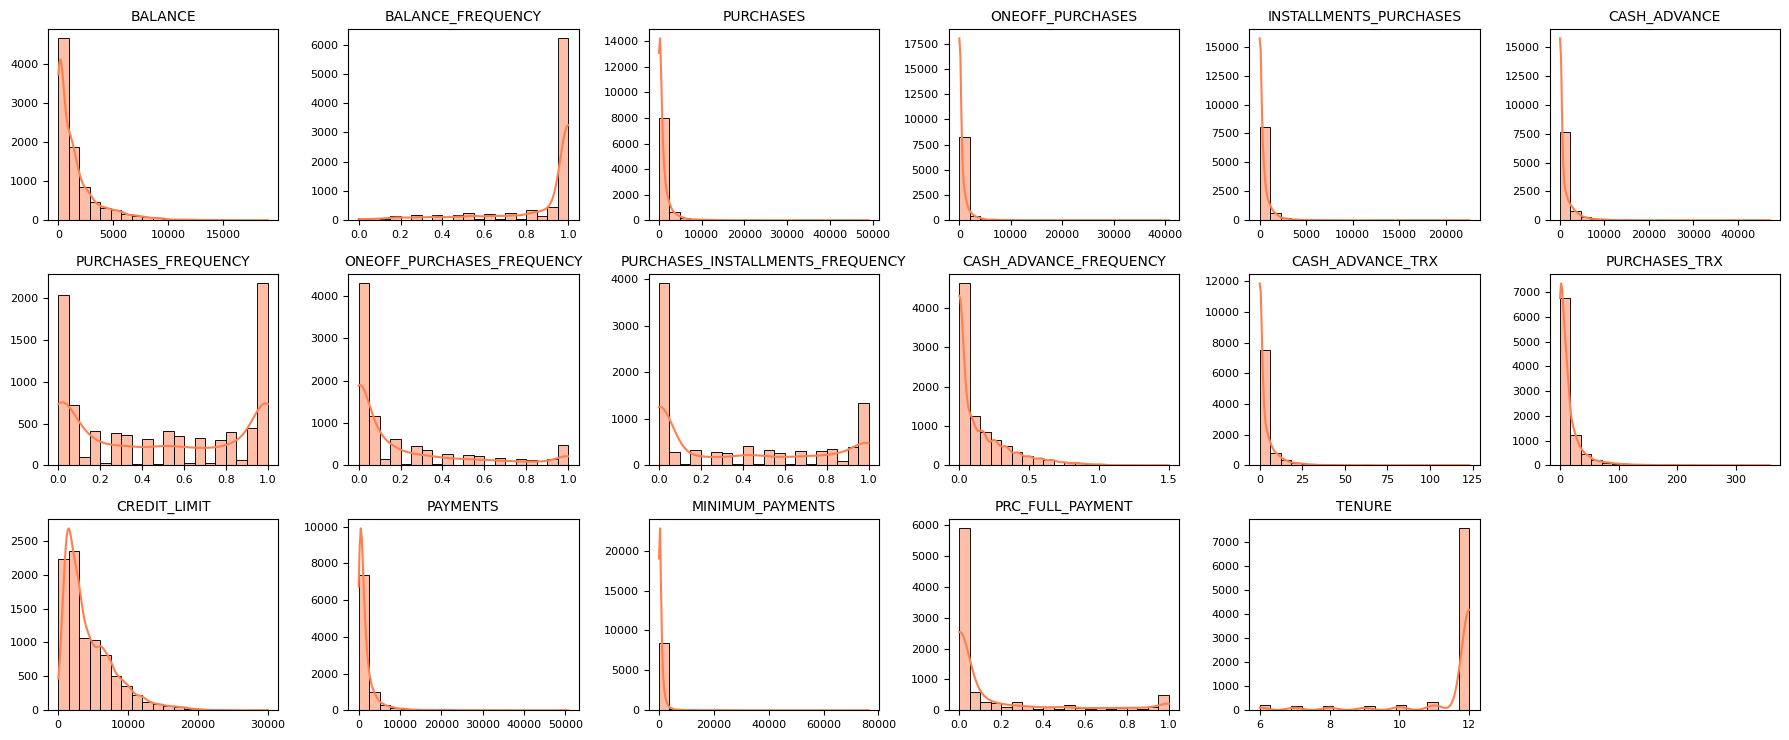

In [11]:
plot_all_features_grid(df.drop('CUST_ID', axis=1), 6)

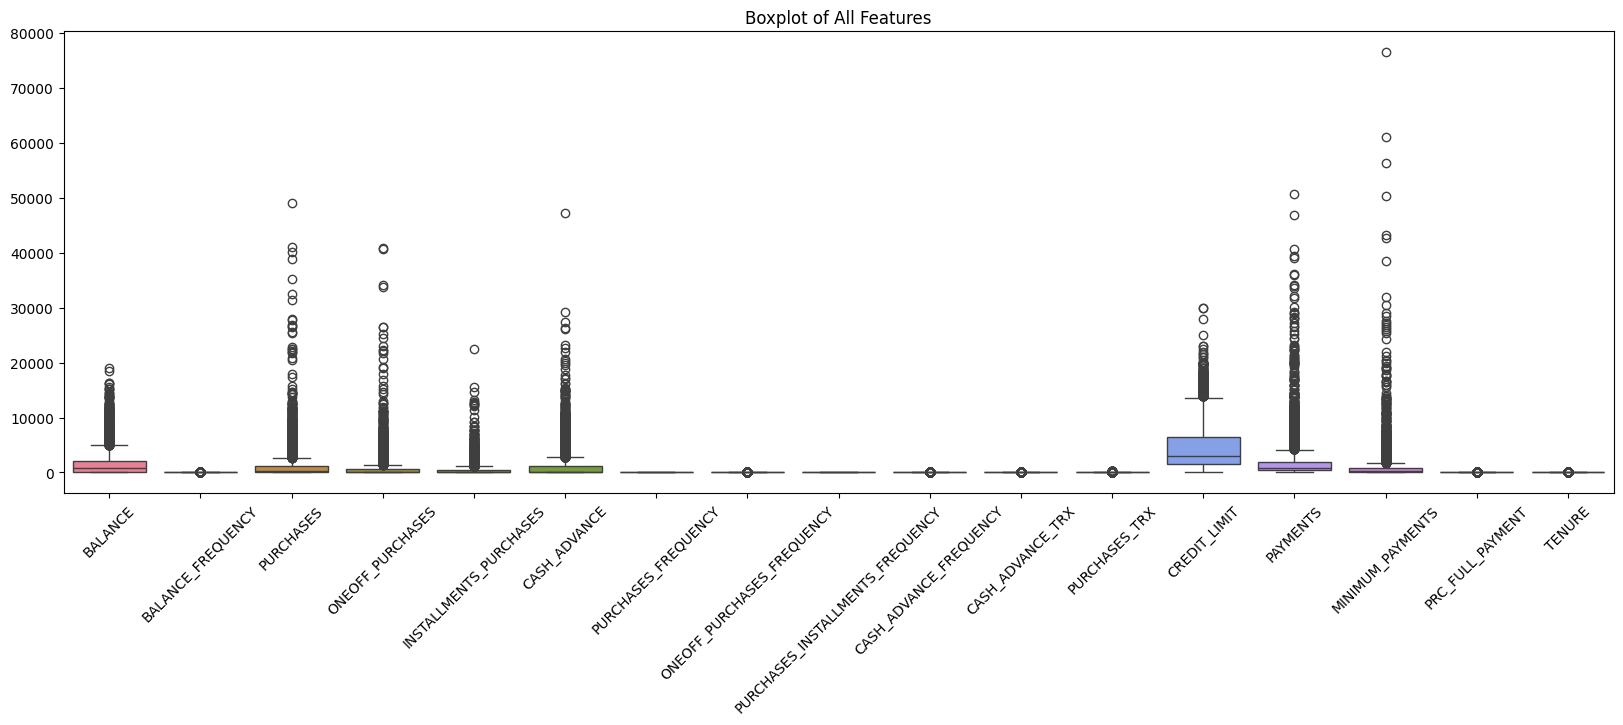

In [ ]:
numerical_cols = df.select_dtypes(include=["float64", "int64"])
plt.figure(figsize=(20, 6))
sns.boxplot(numerical_cols)
plt.xticks(rotation=45)  
plt.title("Boxplot of All Features")
plt.show()

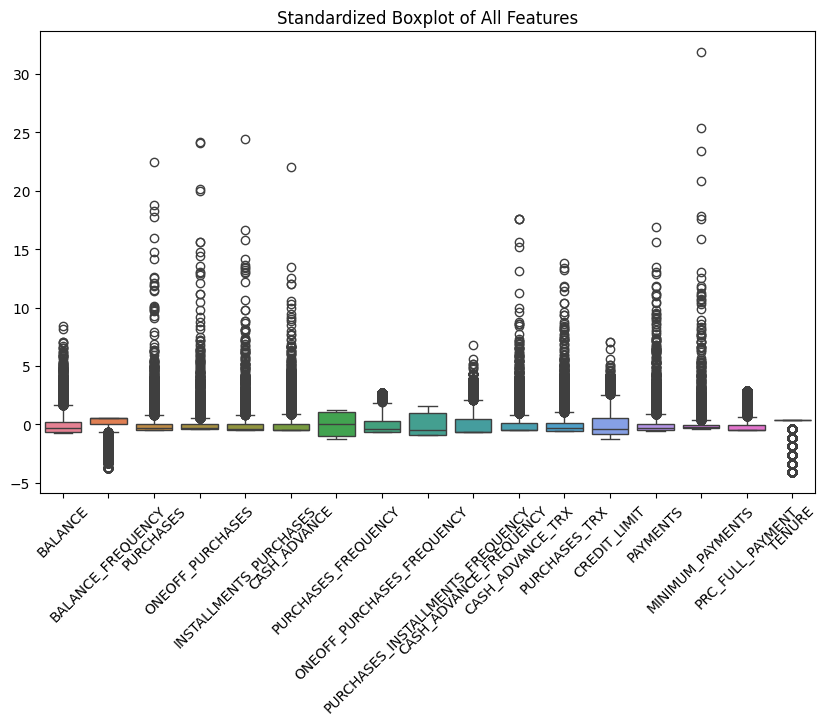

In [ ]:
#standardized
numerical_cols = df.select_dtypes(include=["float64", "int64"])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_cols)
scaled_df = pd.DataFrame(scaled_data, columns=numerical_cols.columns)

plt.figure(figsize=(10, 6))
sns.boxplot(data=scaled_df)
plt.xticks(rotation=45)  
plt.title("Standardized Boxplot of All Features")
plt.show()

Most of the features are right-skewed, particularly features relating to money or wealth such as Purchases, Balance, Credit Limit, and Payments. Thus, it is expected that there are significantly less high spenders due to the low frequency (y-axis) of the aforementioned features that exhibit the higher values (x-axis) of their range. 

##### **Correlation Heatmap**

<Axes: >

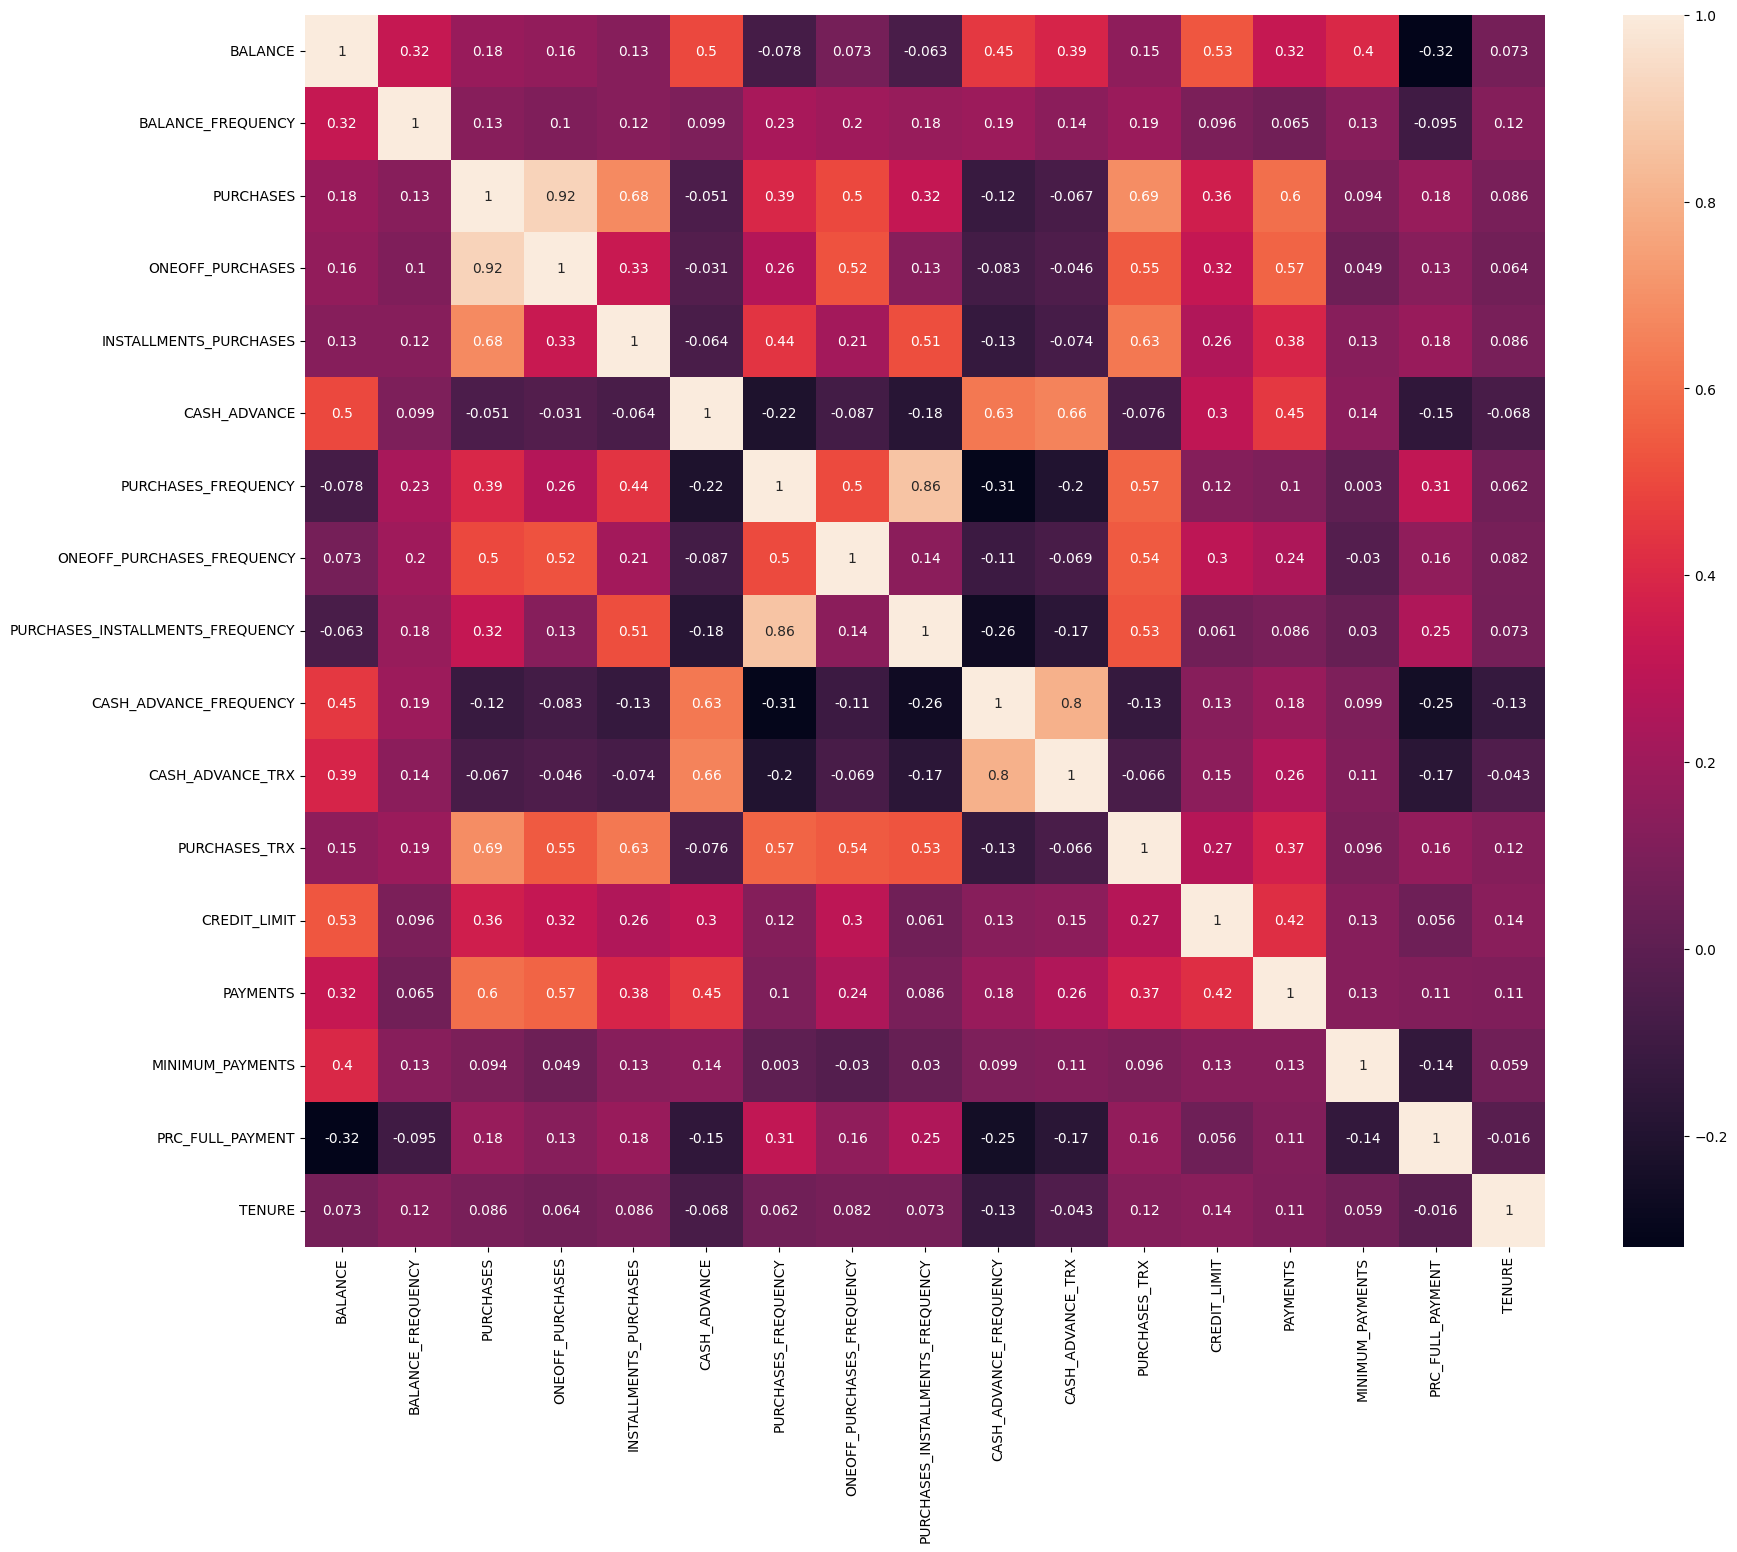

In [25]:
#heatmap correlation
plt.figure(figsize=(20, 16))
sns.heatmap(numerical_cols.corr(), annot=True)

In [ ]:
numerical_cols.corr()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.000000,0.322412,0.181261,0.164350,0.126469,0.496692,-0.077944,0.073166,-0.063186,0.449218,0.385152,0.154338,0.531283,0.322802,0.398684,-0.318959,0.072692
BALANCE_FREQUENCY,0.322412,1.000000,0.133674,0.104323,0.124292,0.099388,0.229715,0.202415,0.176079,0.191873,0.141555,0.189626,0.095843,0.065008,0.132569,-0.095082,0.119776
PURCHASES,0.181261,0.133674,1.000000,0.916845,0.679896,-0.051474,0.393017,0.498430,0.315567,-0.120143,-0.067175,0.689561,0.356963,0.603264,0.093860,0.180379,0.086288
ONEOFF_PURCHASES,0.164350,0.104323,0.916845,1.000000,0.330622,-0.031326,0.264937,0.524891,0.127729,-0.082628,-0.046212,0.545523,0.319724,0.567292,0.048755,0.132763,0.064150
INSTALLMENTS_PURCHASES,0.126469,0.124292,0.679896,0.330622,1.000000,-0.064244,0.442418,0.214042,0.511351,-0.132318,-0.073999,0.628108,0.256499,0.384084,0.132172,0.182569,0.086143
CASH_ADVANCE,0.496692,0.099388,-0.051474,-0.031326,-0.064244,1.000000,-0.215507,-0.086754,-0.177070,0.628522,0.656498,-0.075850,0.303985,0.453238,0.140107,-0.152935,-0.068312
PURCHASES_FREQUENCY,-0.077944,0.229715,0.393017,0.264937,0.442418,-0.215507,1.000000,0.501343,0.862934,-0.308478,-0.203478,0.568430,0.119788,0.103464,0.003030,0.305802,0.061506
ONEOFF_PURCHASES_FREQUENCY,0.073166,0.202415,0.498430,0.524891,0.214042,-0.086754,0.501343,1.000000,0.142329,-0.111716,-0.069088,0.544869,0.295038,0.243537,-0.030327,0.157531,0.082466
PURCHASES_INSTALLMENTS_FREQUENCY,-0.063186,0.176079,0.315567,0.127729,0.511351,-0.177070,0.862934,0.142329,1.000000,-0.262958,-0.169207,0.529975,0.060755,0.085551,0.030073,0.250087,0.073275
CASH_ADVANCE_FREQUENCY,0.449218,0.191873,-0.120143,-0.082628,-0.132318,0.628522,-0.308478,-0.111716,-0.262958,1.000000,0.799561,-0.131168,0.132616,0.183192,0.098838,-0.249773,-0.133372


In [ ]:
#print max correlation coefficient that are less than 1
masked_corr = numerical_cols.corr().replace(1.0, np.nan)
print(masked_corr.max().sort_values(ascending=False))

PURCHASES                           0.916845
ONEOFF_PURCHASES                    0.916845
PURCHASES_INSTALLMENTS_FREQUENCY    0.862934
PURCHASES_FREQUENCY                 0.862934
CASH_ADVANCE_TRX                    0.799561
CASH_ADVANCE_FREQUENCY              0.799561
PURCHASES_TRX                       0.689561
INSTALLMENTS_PURCHASES              0.679896
CASH_ADVANCE                        0.656498
PAYMENTS                            0.603264
ONEOFF_PURCHASES_FREQUENCY          0.544869
BALANCE                             0.531283
CREDIT_LIMIT                        0.531283
MINIMUM_PAYMENTS                    0.398684
BALANCE_FREQUENCY                   0.322412
PRC_FULL_PAYMENT                    0.305802
TENURE                              0.139167
dtype: float64


---
### **2. Clustering**


---
### **3. Cluster Profiles**


---
### **4. Multiple Model Training for Classification**


---
### **5. Performance Metrics**


---
### **6. Conclusion**
